### Setup

In [10]:
# ==========================================
# 1. Setup & Imports
# ==========================================
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import sys
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, f1_score, balanced_accuracy_score, 
    precision_recall_fscore_support, confusion_matrix
)
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
# เพิ่ม path เพื่อเรียกใช้ src
sys.path.append('..')
from src.config import config

# สร้าง Folder ต่างๆ ตาม config ถ้ายังไม่มี
config.setup()

 Directories checked/created at /Users/mati/adv_skin_cancer


### Data Loading Function

In [6]:
def load_and_preprocess_images(csv_path, img_size=(64, 64)):
    """
    โหลดภาพและแปลงเป็น Vector สำหรับ Random Forest
    """
    df = pd.read_csv(csv_path)
    features = []
    labels = []
    
    print(f" Loading images from {csv_path}...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        # โหลดภาพและ Resize ให้เล็กลง (RF ไม่รองรับภาพขนาดใหญ่เท่า CNN)
        img = Image.open(row['image_path']).convert('RGB')
        img = img.resize(img_size)
        
        # แปลงเป็น numpy array และ Flatten เป็น 1D vector (R,G,B)
        img_array = np.array(img).flatten() / 255.0 
        
        features.append(img_array)
        labels.append(config.CLASS_TO_IDX[row['dx']])
        
    return np.array(features), np.array(labels)

### Execution (Train & Eval) 

In [7]:
# โหลดข้อมูล (ใช้ภาพขนาด 64x64 เพื่อไม่ให้ RAM เต็ม)
X_train, y_train = load_and_preprocess_images(config.PROCESSED_DATA_DIR / 'train.csv')
X_test, y_test = load_and_preprocess_images(config.PROCESSED_DATA_DIR / 'test.csv')

print("\n Training Random Forest Baseline...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=config.SEED, 
    n_jobs=-1, 
    class_weight='balanced' # แก้ปัญหา Imbalance เบื้องต้น
)
rf_model.fit(X_train, y_train)

# พยากรณ์ผล
y_pred = rf_model.predict(X_test)

 Loading images from /Users/mati/adv_skin_cancer/data/processed/train.csv...


100%|██████████████████████████████████████| 7054/7054 [00:44<00:00, 160.14it/s]


 Loading images from /Users/mati/adv_skin_cancer/data/processed/test.csv...


100%|██████████████████████████████████████| 1497/1497 [00:09<00:00, 160.95it/s]



 Training Random Forest Baseline...


### Calculation & Saving Metrics

In [8]:
# คำนวณค่าพื้นฐาน
macro_f1 = f1_score(y_test, y_pred, average='macro')
bal_acc = balanced_accuracy_score(y_test, y_pred)

# คำนวณค่าเฉพาะของคลาส Melanoma (mel)
mel_idx = config.CLASS_TO_IDX['mel']
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

# สรุปผลลัพธ์ในรูปแบบ Dictionary
results_summary = {
    "Model Name": "Random Forest (Baseline)",
    "Macro F1": round(macro_f1, 4),
    "Bal. Acc.": round(bal_acc, 4),
    "Mel. Prec.": round(precision[mel_idx], 4),
    "Mel. Rec.": round(recall[mel_idx], 4),
    "Mel. F1": round(f1[mel_idx], 4)
}

# --- บันทึกลงไฟล์ CSV ---
save_csv_path = config.METRIC_DIR / 'rf_baseline_results.csv'
df_results = pd.DataFrame([results_summary])
df_results.to_csv(save_csv_path, index=False)

# --- บันทึกตัวโมเดล (.joblib) ---
model_save_path = config.MODEL_DIR / 'rf_baseline_model.joblib'
joblib.dump(rf_model, model_save_path)

/Users/mati/adv_skin_cancer/skin_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


['/Users/mati/adv_skin_cancer/models/rf_baseline_model.joblib']

### Display Results

In [9]:
print("\n" + "="*40)
print(" FINAL RESULTS (Saved to CSV)")
print("="*40)
print(df_results.to_string(index=False))

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES, digits=4))


 FINAL RESULTS (Saved to CSV)
              Model Name  Macro F1  Bal. Acc.  Mel. Prec.  Mel. Rec.  Mel. F1
Random Forest (Baseline)    0.2754     0.2528       0.375     0.0179   0.0341

Detailed Report:
              precision    recall  f1-score   support

       akiec     0.5625    0.1765    0.2687        51
         bcc     0.5217    0.3117    0.3902        77
         bkl     0.4432    0.2484    0.3184       157
          df     0.0000    0.0000    0.0000        22
         mel     0.3750    0.0179    0.0341       168
          nv     0.7250    0.9700    0.8298      1000
        vasc     1.0000    0.0455    0.0870        22

    accuracy                         0.6987      1497
   macro avg     0.5182    0.2528    0.2754      1497
weighted avg     0.6335    0.6987    0.6220      1497



/Users/mati/adv_skin_cancer/skin_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mati/adv_skin_cancer/skin_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mati/adv_skin_cancer/skin_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

 Saved Confusion Matrix to: /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_rf_baseline.png
 Saved Text Report to: /Users/mati/adv_skin_cancer/reports/metrics/classification_report_rf_baseline.txt


/Users/mati/adv_skin_cancer/skin_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mati/adv_skin_cancer/skin_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mati/adv_skin_cancer/skin_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

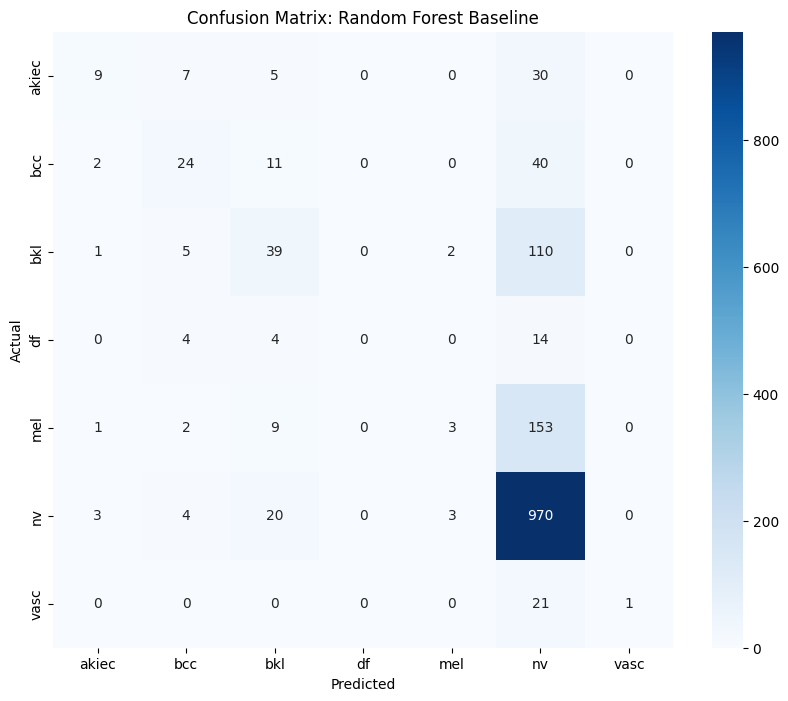

In [12]:
# --- 1. วาด Confusion Matrix (เพิ่มส่วนนี้) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=config.CLASS_NAMES,
    yticklabels=config.CLASS_NAMES
)
plt.title(f"Confusion Matrix: Random Forest Baseline")
plt.xlabel('Predicted')
plt.ylabel('Actual')

# บันทึกภาพลงโฟลเดอร์เดียวกับรุ่นอื่นๆ
save_path_cm = config.FIGURE_DIR / 'confusion_matrix_rf_baseline.png'
plt.savefig(save_path_cm, dpi=300)
print(f" Saved Confusion Matrix to: {save_path_cm}")

# --- 2. บันทึก Full Text Report (เพิ่มส่วนนี้) ---
report_txt = classification_report(y_test, y_pred, target_names=config.CLASS_NAMES, digits=4)
report_path = config.METRIC_DIR / 'classification_report_rf_baseline.txt'
with open(report_path, 'w') as f:
    f.write("Model: Random Forest Baseline\n")
    f.write(report_txt)
print(f" Saved Text Report to: {report_path}")

plt.show()